In [ ]:
import marimo as mo
import urllib.request as req

mo.Html(
    f"<style>{req.urlopen('https://raw.githubusercontent.com/janithcyapa/Engineering-Codex/refs/heads/main/shared_files/marimo/theme.css').read().decode()}</style>"
)

In [ ]:
import schemdraw
import schemdraw.elements as elm

# Modeling a thermal zone using an RC (Resistor-Capacitor) model

### 1. Temperature & Heat Transfer (Sensible Heat)
| Symbol | Definition | Unit |
| :--- | :--- | :--- |
| $T_{in}$ | Indoor air temperature of the zone | $K$ or $^\circ C$ |
| $T_m$| Temperature of the building's thermal mass | $K$ or $^\circ C$ |
| $T_{out}$ | Outdoor ambient air temperature | $K$ or $^\circ C$ |
| $T_s$ | Temperature of the HVAC supply air | $K$ or $^\circ C$ |
| $Q_{int}$ | Internal sensible heat gains (occupants, equipment, lighting) | $W$ |
| $Q_{solar}$ | Solar radiation heat entering through windows | $W$ |
| $Q_s$ | Sensible heating or cooling energy from HVAC | $W$ |
| $Q_{vent}$ | Heat transfer due to ventilation and air infiltration | $W$ |

---

### 2. Humidity & Moisture (Latent Heat)
| Symbol | Definition | Unit |
| :--- | :--- | :--- |
| $W_{in}$ | Indoor humidity ratio | $kg_{w}/kg_{da}$ |
| $W_{out}$ | Outdoor humidity ratio | $kg_{w}/kg_{da}$ |
| $W_s$ | HVAC supply air humidity ratio | $kg_{w}/kg_{da}$ |
| $P_v$ | Vapor pressure in the air | $Pa$ |
| $\dot{m}_{lat}$ | Internal moisture generation rate | $kg_{w}/s$ |
| $\dot{m}_{vent}$ | Moisture rate brought in/removed by ventilation | $kg_{w}/s$ |
| $\dot{m}_{s}$ | Dehumidification rate by the air conditioning system | $kg_{w}/s$ |

---

### 3. $CO_2$ Concentration
| Symbol | Definition | Unit |
| :--- | :--- | :--- |
| $C_{in}$ | Indoor $CO_2$ concentration | $ppm$ or $mg/m^3$ |
| $C_{out}$ | Outdoor $CO_2$ concentration | $ppm$ |
| $C_s$ | $CO_2$ concentration of the HVAC supply air | $ppm$ |
| $\dot{C}_{in}$ | Internal $CO_2$ generation rate (occupants) | $kg/s$ or $L/s$ |

---

### 4. Airflows & Control Inputs
| Symbol | Definition | Unit |
| :--- | :--- | :--- |
| $\dot{m}_{s}$ | Mass flow rate of HVAC supply air (Control Input) | $kg/s$ |
| $\dot{m}_{inf}$ | Mass flow rate of uncontrolled air infiltration | $kg/s$ |
| $\dot{V}_{vent}$ | Volumetric flow rate of ventilation and infiltration | $m^3/s$ |

---

### 5. Physical Constants & Building Parameters
| Symbol | Definition | Unit |
| :--- | :--- | :--- |
| $C_{air}$ | Thermal capacity of the room's air volume | $J/K$ |
| $C_{mass}$ | Thermal capacity of the building mass | $J/K$ |
| $C_m$ | Moisture storage capacity of the air ($\rho_{air} \cdot V_{room}$) | $kg$ |
| $R_{env}$ | Thermal resistance of the building envelope | $K/W$ |
| $R_{in}$ | Thermal resistance between indoor air and building mass | $K/W$ |
| $M_{air}$ | Total mass of the air inside the room | $kg$ |
| $V_{room}$ | Total volume of the room | $m^3$ |
| $\rho_{air}$ | Density of the room air | $kg/m^3$ |
| $c_p$ | Specific heat capacity of air | $J/(kg \cdot K)$ |

## The Fundamental Electrical Analogy

Before diving into the specific variables, it is crucial to understand the mapping between the physical world and the electrical RC circuit.

- **Potential** (Voltage, $V$): The driving force (e.g., Temperature difference, Concentration difference).
- **Flow** (Current, $I$): The rate of transfer (e.g., Heat flux, Mass flow rate).
- **Resistance** (Resistor, $R$): Resistance to flow (e.g., Insulation, Reciprocal of ventilation rate).
- **Storage** (Capacitor, $C$): The capacity to store energy or mass (e.g., Thermal mass, Room air volume).

### 1. Modeling Room Temperature (Thermal RC Model)

A single room or thermal zone is typically modeled using a 1R1C, 2R1C, or 2R2C (or higher-order 3R2C) resistance-capacitance network, depending on the required accuracy and the importance of thermal mass dynamics. The 2-node model (2R2C) is a good compromise, it separates the fast dynamics of the room air from the slower response of the building's thermal mass (walls, floor, furniture, etc.).

The Analogy:Voltage ($T$):
- Temperature ($^\circ C$ or $K$). Nodes represent the outdoor air ($T_{out}$), indoor air ($T_{in}$), and wall mass ($T_{w}$).
- Current ($Q$): Heat flow ($W$).
- Resistance ($R$): Thermal resistance of walls, windows, and infiltration ($K/W$).
- Capacitor ($C$): Thermal capacitance of the indoor air and internal mass ($J/K$).

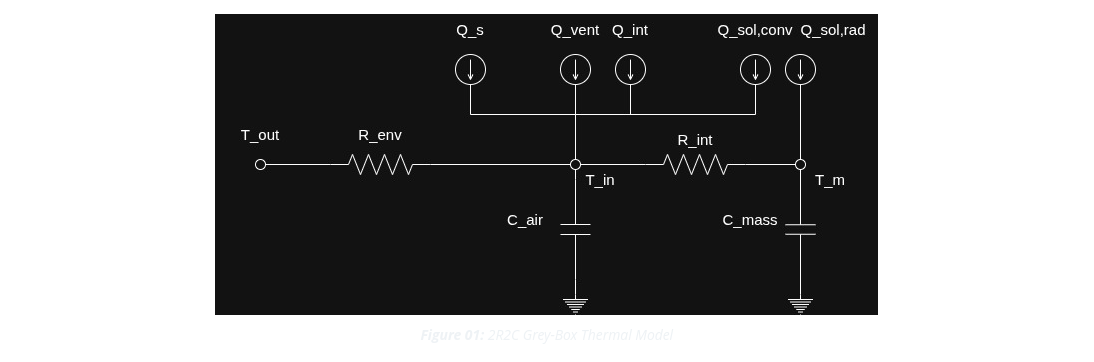

In [ ]:
mo.vstack(
    [
        mo.image(
            src="https://raw.githubusercontent.com/janithcyapa/DHCA-Framework/main/Images/2R2C_Temp_Model.jpg",
            alt="2R2C Thermal RC Network"
        ),
        mo.md("<div style='text-align: center; font-style: italic;'><b>Figure 01:</b> 2R2C Grey-Box Thermal Model</div>")
    ],
    align="center"
)

The Governing Equation

If we treat the room air and light furniture as a single node, the first-order differential equation is

$$C_{air} \frac{dT_{in}}{dt} = \sum \frac{T_{out} - T_{in}}{R_{env}} + \frac{T_{m} - T_{in}}{R_{int}} + Q_{int} + Q_{solar,conv} +  Q_{s} + Q_{vent}$$

For the mass node,
$$ C_{mass} \frac{dT_m}{dt} = \frac{T_{in} - T_m}{R_{int}} + Q_{solar,rad} $$

Where:
- $C_{air}$: Thermal capacity of the room air.
- $R_{int}$: Equivalent thermal resistance of the building envelope (walls, windows).
- $C_{C_mass}$: Effective thermal capacity of the internal mass.
- $R_{env}$: Air-to-mass coupling resistance (K/W).
- $Q_{int}$: Internal heat gains (people, equipment, lighting).
- $Q_{solar}$: Solar radiation entering through windows.
- $Q_{s}$: Heating or cooling provided by the system.
- $Q_{vent}$: Heat transfer due to ventilation/infiltration, modeled as $\dot{m} c_p (T_{out} - T_{in})$.

Notes on the Model

- This 2-node setup captures both the quick response of room air temperature and the inertial effect of thermal mass, making it more accurate than a pure 1C lumped model for dynamic simulations, model predictive control (MPC), or overheating risk assessment.
- In practice, parameters (R_env, R_int, C_air, C_mass) can be calculated from building geometry and material properties or identified from measured data.
For even higher accuracy, models are extended to 3R2C or the full 5R1C from ISO 13790.

### 2. Modeling Humidity

Humidity can be modeled similarly, though it is usually treated as a mass balance. In an RC framework, it is generally a 1C model (just the room air), unless you want to model the moisture absorbed by walls and furniture (hygroscopic buffering), which would require additional R and C components.

The Analogy:
- Voltage ($W$ or $P_v$): Humidity ratio ($kg_{water}/kg_{dry\ air}$) or Vapor pressure ($Pa$).
- Current ($\dot{m}_w$): Moisture mass flow rate ($kg/s$).
- Capacitor ($C_m$): Moisture storage capacity of the air. $C_m = \rho_{air} \cdot V_{room}$ (where $V$ is volume).

The Governing Equation (Lumped Air Node):

$$\rho_{air} V_{room} \frac{dW_{in}}{dt} = \dot{m}_{int} + \dot{m}_{vent} - \dot{m}_{s}$$

Where:
- $W_{in}$: Indoor humidity ratio.
- $\dot{m}_{int}$: Internal moisture generation (breathing, sweating, cooking).$
- $\dot{m}_{vent}$: Moisture brought in or removed by ventilation: $\dot{V}_{vent} \rho_{air} (W_{out} - W_{in})$.
- $\dot{m}_{s}$: Dehumidification rate from the AC system.

### 3. Modeling $CO_2$ Concentration (Mass Transfer Model)

$CO_2$ modeling is the most straightforward of the three. Because $CO_2$ does not absorb into walls or furniture like moisture or heat, it is almost strictly a 1C model (pure mass balance). The "capacitor" is simply the volume of the room.

The Analogy:
- Voltage ($C$): $CO_2$ concentration, usually in $ppm$ (parts per million) or $mg/m^3$.
- Current ($G$): $CO_2$ generation rate ($mg/s$ or $L/s$).
- Resistance ($R$): The inverse of the ventilation rate ($1 / \dot{V}_{vent}$).
- Capacitor ($C_{vol}$): The volume of the room ($V_{room}$).The

The Governing Equation:
$$V_{room} \frac{dC_{in}}{dt} = G_{int} + \dot{V}_{vent}(C_{out} - C_{in})$$

Where:
- $C_{in}$: Indoor $CO_2$ concentration.
- $C_{out}$: Outdoor $CO_2$ concentration (typically around 400-420 ppm).
- $G_{int}$: Internal $CO_2$ generation rate (primarily from occupants).
- $\dot{V}_{vent}$: Volumetric flow rate of ventilation and infiltration.

## Dynamic System Derivation For a Zone

### Multi-Room **xR2C** Thermal Model

In a multizone termal node there is a coupling effect. Which is not included in the standard 2R2C or any other static modeling methord. So I proporce this dynamic **xR2C** model which generated based on the bulding geometry.

- **x **= number of resistances (K/W) → heat flow paths (envelope, internal partitions, convection/radiation, ventilation).


**Per-zone core structure**

Each thermal zone is represented by its own local RC sub-network (typically a 2R2C structure with an air node $T_{in,i}$ and a mass node $T_{m,i}$, connected by resistances $R_{\text{env},i}$ and $R_{\text{int},i}$, and capacitances $C_{\text{air},i}$ and $C_{\text{mass},i}$.

Geometry-dependent dynamic coupling

Additional resistances (or conductances) are introduced between zones to model inter-zone heat transfer. These coupling terms ($R_{\text{couple},ij}$) are not fixed constants but are dynamically derived from the building’s physical layout.

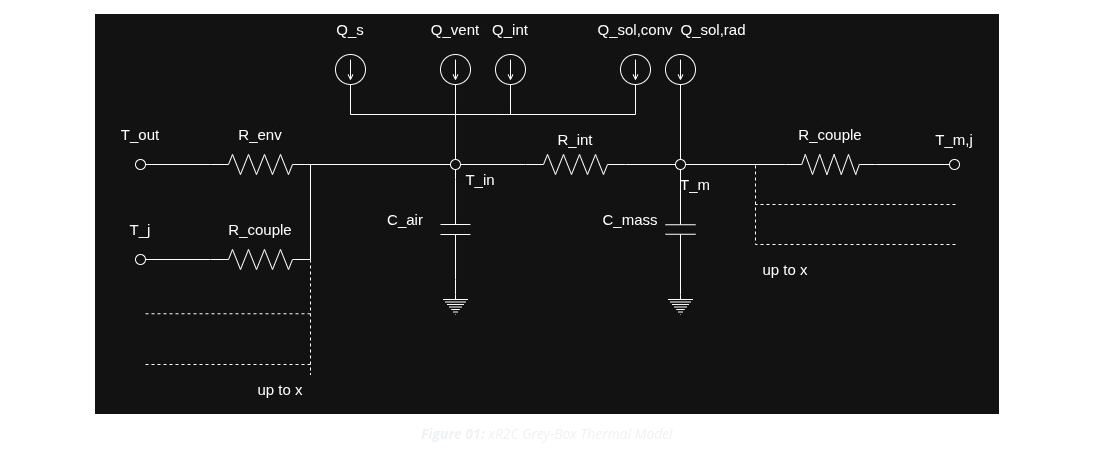

In [ ]:
mo.vstack(
    [
        mo.image(
            src="https://raw.githubusercontent.com/janithcyapa/DHCA-Framework/main/Images/xR2C_Temp_Model.jpg",
            alt="xR2C Thermal RC Network"
        ),
        mo.md("<div style='text-align: center; font-style: italic;'><b>Figure 01:</b> xR2C Grey-Box Thermal Model</div>")
    ],
    align="center"
)

**Governing Differential Equations**

For each zone i = 1, 2, ..., N (where N is the number of zones),

Air node equation (for $T_{a,i}$):
$$C_{\text{air},i} \frac{dT_{in,i}}{dt} = \frac{T_{\text{out}} - T_{in,i}}{R_{\text{env},i}} + \frac{T_{m,i} - T_{in,i}}{R_{\text{int},i}} + \sum_{j \in \text{adj}(i)} \frac{T_{in,j} - T_{in,i}}{R_{\text{couple},ij}} + Q_{\text{int},i} + Q_{\text{solar,conv},i} + Q_{s,i} + Q_{\text{vent},i}$$

Mass node equation (for $  T_{m,i}  $):
$$C_{\text{mass},i} \frac{dT_{m,i}}{dt} = \frac{T_{in,i} - T_{m,i}}{R_{\text{int},i}} + Q_{\text{solar,rad},i} + \sum_{j \in \text{adj}(i)} \frac{T_{m,j} - T_{m,i}}{R_{\text{couple,ms},ij}} $$